In [5]:
import pandas as pd
import re
import random
import os
import gc
import json
import pickle
import shutil
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torch.optim import AdamW

from transformers import (
    BertForSequenceClassification,
    BertTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    auc,
    average_precision_score
)


# Data Loading

In this step, the dataset is loaded from a CSV file into a pandas DataFrame. This dataset contains job postings labeled as real or fraudulent.

In [6]:
# Load your dataset
df_raw = pd.read_csv('fake_job_postings.csv')

# Preview data
df_raw.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Initial Data Exploration

We perform an initial inspection of the dataset to understand its structure, data types, and identify missing values.

Key checks:
- Data shape
- Column types
- Missing values distribution
- Target variable balance (fraudulent vs non-fraudulent)

In [7]:
df_raw.shape

(17880, 18)

In [8]:
# Check missing values
missing_values = df_raw.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [9]:
df_raw['location'].value_counts().head(20)

,count
location,
"GB, LND, London",718
"US, NY, New York",658
"US, CA, San Francisco",472
"GR, I, Athens",464
"US, ,",339
"US, TX, Houston",269
"US, IL, Chicago",255
"US, DC, Washington",251
"DE, BE, Berlin",221


In [10]:
df_raw['fraudulent'].value_counts().head(20)

,count
fraudulent,
0,17014
1,866


In [11]:
df_raw['country'] = df_raw['location'].str.split(',').str[0].str.strip()

df_raw['country'].value_counts().head(20)

,count
country,
US,10656
GB,2384
GR,940
CA,457
DE,383
NZ,333
IN,276
AU,214
PH,132


In [12]:
fraud_df = df_raw[df_raw['fraudulent'] == 1]

fraud_by_country = fraud_df['country'].value_counts()

fraud_by_country.head(10)

,count
country,
US,730
AU,40
GB,23
MY,12
CA,12
QA,6
BH,5
IN,4
PL,3


# Data Cleaning & Preparation

A copy of the raw dataset is created to preserve the original data. Irrelevant columns such as 'salary_range' and 'department' are removed as they are not essential for text-based classification.

In [13]:
# Drop rows with missing values
df_clean_desc = df_raw.dropna(subset=['description'])


print("Shape before cleaning:", df_raw.shape)
print("Shape after cleaning:", df_clean_desc.shape)
print(df_clean_desc.columns)

Shape before cleaning: (17880, 19)
Shape after cleaning: (17879, 19)
Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent', 'country'],
      dtype='object')


In [14]:
drop_cols = ['salary_range', 'department']
df_clean = df_clean_desc.drop(columns=drop_cols)

print("Before:", df_clean_desc.shape)
print("After:", df_clean.shape)

Before: (17879, 19)
After: (17879, 17)


In [15]:
# BEFORE: Full dataset
total_before = len(df_raw)
fraud_before = df_raw['fraudulent'].sum()
real_before = total_before - fraud_before

print("=== BEFORE (Full Dataset) ===")
print(f"Total: {total_before}")
print(f"Fraudulent: {fraud_before}")
print(f"Legitimate: {real_before}")
print(f"Fraud %: {fraud_before / total_before:.2%}")

=== BEFORE (Full Dataset) ===
Total: 17880
Fraudulent: 866
Legitimate: 17014
Fraud %: 4.84%


In [16]:
# AFTER: US dataset
df_us = df_raw[df_raw['country'] == 'US']

total_after = len(df_us)
fraud_after = df_us['fraudulent'].sum()
real_after = total_after - fraud_after

print("\n=== AFTER (US Dataset) ===")
print(f"Total: {total_after}")
print(f"Fraudulent: {fraud_after}")
print(f"Legitimate: {real_after}")
print(f"Fraud %: {fraud_after / total_after:.2%}")


=== AFTER (US Dataset) ===
Total: 10656
Fraudulent: 730
Legitimate: 9926
Fraud %: 6.85%


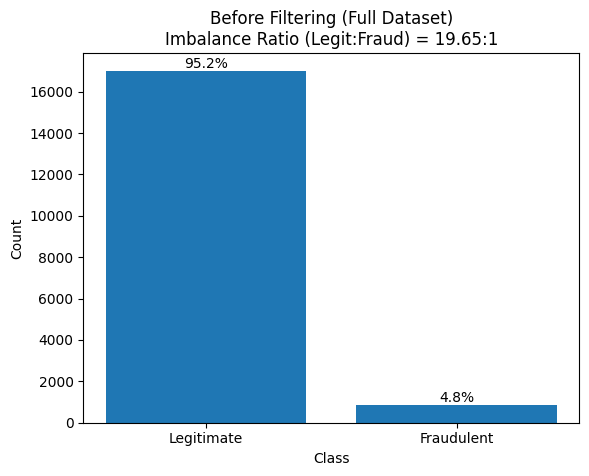

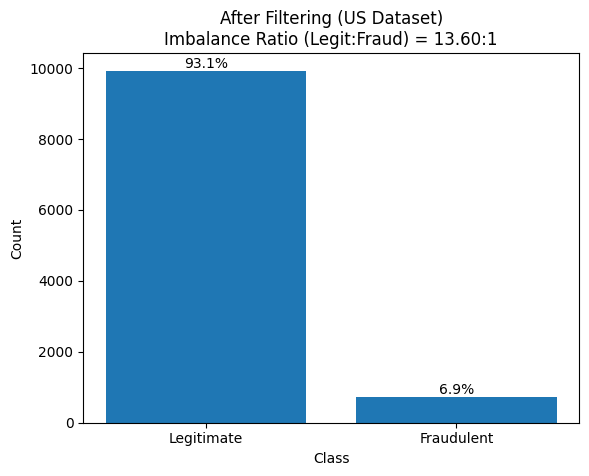

In [17]:
import matplotlib.pyplot as plt

def plot_distribution(title, legit, fraud):
    total = legit + fraud

    labels = ['Legitimate', 'Fraudulent']
    counts = [legit, fraud]

    # Percentages
    percentages = [(c / total) * 100 for c in counts]

    plt.figure()
    bars = plt.bar(labels, counts)

    # Add percentage labels on top
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{pct:.1f}%',
                 ha='center', va='bottom')

    # Imbalance ratio
    ratio = legit / fraud if fraud != 0 else 0
    plt.title(f"{title}\nImbalance Ratio (Legit:Fraud) = {ratio:.2f}:1")

    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()


# BEFORE
plot_distribution(
    "Before Filtering (Full Dataset)",
    real_before,
    fraud_before
)

# AFTER
plot_distribution(
    "After Filtering (US Dataset)",
    real_after,
    fraud_after
)

# Filtering US Job Postings

The dataset is filtered to include only job postings from the United States. This ensures consistency in language and reduces noise from international variations.

In [18]:
# Filter dataset to include only US job postings
df_us = df_clean[df_clean['country'] == 'US'].copy()

print(df_us.shape)
print(df_us.columns)

(10656, 17)
Index(['job_id', 'title', 'location', 'company_profile', 'description',
       'requirements', 'benefits', 'telecommuting', 'has_company_logo',
       'has_questions', 'employment_type', 'required_experience',
       'required_education', 'industry', 'function', 'fraudulent', 'country'],
      dtype='object')


# Handling Missing Values

Missing values in textual columns are filled with the string "missing". This ensures that no data is lost while preserving information about missing fields, which may be indicative of fraudulent postings.

In [19]:
# Check missing values
missing_values_us = df_us.isnull().sum()

print("Missing values per column:")
print(missing_values_us)

Missing values per column:
job_id                    0
title                     0
location                  0
company_profile        2076
description               0
requirements           1775
benefits               4683
telecommuting             0
has_company_logo          0
has_questions             0
employment_type        1762
required_experience    4284
required_education     4477
industry               2682
function               3904
fraudulent                0
country                   0
dtype: int64


In [20]:
df_us['fraudulent'].value_counts().head(20)

,count
fraudulent,
0,9926
1,730


In [21]:
# Replace missing values with 'missing' to retain information
text_cols = ['title', 'description', 'company_profile', 'requirements', 'benefits']

df_us[text_cols] = df_us[text_cols].fillna('missing')

cat_cols = ['employment_type','required_experience', 'required_education', 'industry', 'function']

df_us[cat_cols] = df_us[cat_cols].fillna('unknown')

In [22]:
# Check missing values
missing_values_us = df_us.isnull().sum()

print("Missing values per column:")
print(missing_values_us)

Missing values per column:
job_id                 0
title                  0
location               0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
country                0
dtype: int64


# Feature Engineering

Additional features are created to enhance the model's ability to detect fraudulent job postings:

- Missing indicators: Flags for missing 'requirements', 'company_profile', and 'benefits'
- has_number: Detects presence of numbers in job descriptions (potential scam indicator)
- desc_length: Measures the length of job descriptions (fake jobs tend to be shorter)

In [23]:
df_us['missing_requirements'] = (df_us['requirements'] == "missing").astype(int)
df_us['missing_company_profile'] = (df_us['company_profile'] == "missing").astype(int)
df_us['missing_benefits'] = (df_us['benefits'] == "missing").astype(int)

df_us['has_number'] = df_us['description'].str.contains(r'\d').astype(int)

# Feature: length of job description (fake jobs tend to be shorter)
df_us['desc_length'] = df_us['description'].str.split().str.len()

df_us[['missing_requirements','missing_company_profile','missing_benefits']].mean()

,0
missing_requirements,0.166573
missing_company_profile,0.194820
missing_benefits,0.439471


# Text Preprocessing

Text cleaning is applied to normalize the data:
- Convert text to lowercase
- Remove newline characters
- Remove extra whitespace
- Remove URLs
- Remove HTML

Minimal preprocessing is used to preserve semantic meaning, which is important for transformer-based models like BERT.

In [24]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    return text.strip()

us_cols = [
    'title',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'industry',
    'function'
]

for col in us_cols:
    df_us[col] = df_us[col].apply(clean_text)

In [25]:
# Combine all relevant text fields into a single input for BERT
df_us['full_text'] = (
    "TITLE: " + df_us['title'] + " " +
    "DESC: " + df_us['description'] + " " +
    "REQ: " + df_us['requirements'] + " " +
    "COMPANY: " + df_us['company_profile'] + " " +
    "BENEFITS: " + df_us['benefits'] + " " +
    "INDUSTRY: " + df_us['industry'] + " " +
    "FUNCTION: " + df_us['function']
)

# Save Processed Dataset

The cleaned and processed dataset is saved for use in model training and evaluation.

In [26]:
# Save cleaned dataset
df_us.to_csv('job_scam_cleaned.csv', index=False)

# Training / Validation / Test Dataset Split

In [27]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df_us,
    test_size=0.3,
    stratify=df_us['fraudulent'],
    random_state=42
)

# split 30% into 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['fraudulent'],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

7459 1598 1599


In [28]:
print("Train distribution:\n", train_df['fraudulent'].value_counts(normalize=True))
print("Val distribution:\n", val_df['fraudulent'].value_counts(normalize=True))
print("Test distribution:\n", test_df['fraudulent'].value_counts(normalize=True))

Train distribution:
 fraudulent
0    0.931492
1    0.068508
Name: proportion, dtype: float64
Val distribution:
 fraudulent
0    0.93179
1    0.06821
Name: proportion, dtype: float64
Test distribution:
 fraudulent
0    0.931207
1    0.068793
Name: proportion, dtype: float64


In [29]:
import torch

y_train = torch.tensor(train_df['fraudulent'].values)
y_val   = torch.tensor(val_df['fraudulent'].values)
y_test  = torch.tensor(test_df['fraudulent'].values)

# Tokenization

Tokenization is performed using the pre-trained tokenizer associated with the transformer model, ensuring compatibility with BERT and RoBERTa input formats

BERT Tokenization

In [30]:
from transformers import BertTokenizer

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

train_bert = tokenizer_bert(
    train_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

val_bert = tokenizer_bert(
    val_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

test_bert = tokenizer_bert(
    test_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT Validation

In [31]:
print("Train shape:", train_bert['input_ids'].shape)
print("Val shape:", val_bert['input_ids'].shape)
print("Test shape:", test_bert['input_ids'].shape)

assert train_bert['input_ids'].shape[0] == len(y_train)
assert val_bert['input_ids'].shape[0] == len(y_val)
assert test_bert['input_ids'].shape[0] == len(y_test)

print("Sample length:", len(train_bert['input_ids'][0]))
print("All checks passed ✅")

Train shape: torch.Size([7459, 256])
Val shape: torch.Size([1598, 256])
Test shape: torch.Size([1599, 256])
Sample length: 256
All checks passed ✅


RoBERTa Tokenization

In [32]:
from transformers import RobertaTokenizer

tokenizer_roberta = RobertaTokenizer.from_pretrained('roberta-base')

train_roberta = tokenizer_roberta(
    train_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

val_roberta = tokenizer_roberta(
    val_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

test_roberta = tokenizer_roberta(
    test_df['full_text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

RoBERTa validation

In [33]:
print("Train shape:", train_roberta['input_ids'].shape)
print("Val shape:", val_roberta['input_ids'].shape)
print("Test shape:", test_roberta['input_ids'].shape)

assert train_roberta['input_ids'].shape[0] == len(y_train)
assert val_roberta['input_ids'].shape[0] == len(y_val)
assert test_roberta['input_ids'].shape[0] == len(y_test)

print("Sample length:", len(train_roberta['input_ids'][0]))
print("All checks passed ✅")

Train shape: torch.Size([7459, 256])
Val shape: torch.Size([1598, 256])
Test shape: torch.Size([1599, 256])
Sample length: 256
All checks passed ✅


## BERT MODEL


In [34]:
# ============================================================
# BERT MODEL — Random Search Tuning Pipeline
# Fair comparison version for BERT vs RoBERTa
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print("WARNING: CUDA GPU is not available. BERT training will be very slow on CPU.")

Using device: cuda
GPU: Tesla T4


In [35]:
# ============================================================
# 2. BERT tokenizer
# ============================================================

tokenizer_bert = BertTokenizer.from_pretrained("bert-base-uncased")


# ============================================================
# 3. Runtime configuration
# ============================================================

MAX_LENGTH = 192

# Baseline BERT config
BASELINE_EPOCHS = 2
BASELINE_BATCH_SIZE = 16
BASELINE_LR = 2e-5
BASELINE_WEIGHT_DECAY = 0.01
BASELINE_WARMUP_RATIO = 0.1

# Random search config
N_RANDOM_TRIALS = 5
TUNE_TRAIN_FRACTION = 0.35
TUNE_VAL_FRACTION = 1.00

# Final tuned training config
FINAL_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 1

# Speed-up during random search
FREEZE_LOWER_LAYERS_DURING_TUNING = True
NUM_UNFROZEN_ENCODER_LAYERS = 4

NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

print({
    "MAX_LENGTH": MAX_LENGTH,
    "N_RANDOM_TRIALS": N_RANDOM_TRIALS,
    "TUNE_TRAIN_FRACTION": TUNE_TRAIN_FRACTION,
    "FINAL_EPOCHS": FINAL_EPOCHS,
    "FREEZE_LOWER_LAYERS_DURING_TUNING": FREEZE_LOWER_LAYERS_DURING_TUNING
})


{'MAX_LENGTH': 192, 'N_RANDOM_TRIALS': 5, 'TUNE_TRAIN_FRACTION': 0.35, 'FINAL_EPOCHS': 3, 'FREEZE_LOWER_LAYERS_DURING_TUNING': True}


In [36]:
# ============================================================
# 4. Dataset with dynamic padding
# ============================================================

class BertJobDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=192):
        self.texts = list(texts)

        if torch.is_tensor(labels):
            self.labels = labels.cpu().numpy()
        else:
            self.labels = np.asarray(labels)

        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        encoded["labels"] = int(self.labels[idx])
        return encoded


def make_loader(dataset, batch_size, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=DataCollatorWithPadding(tokenizer=tokenizer_bert),
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )


bert_train_dataset = BertJobDataset(
    train_df["full_text"].tolist(),
    y_train,
    tokenizer_bert,
    max_length=MAX_LENGTH
)

bert_val_dataset = BertJobDataset(
    val_df["full_text"].tolist(),
    y_val,
    tokenizer_bert,
    max_length=MAX_LENGTH
)

bert_test_dataset = BertJobDataset(
    test_df["full_text"].tolist(),
    y_test,
    tokenizer_bert,
    max_length=MAX_LENGTH
)

print("BERT train size:", len(bert_train_dataset))
print("BERT validation size:", len(bert_val_dataset))
print("BERT test size:", len(bert_test_dataset))

BERT train size: 7459
BERT validation size: 1598
BERT test size: 1599


In [37]:
# ============================================================
# 5. Class weights for imbalanced scam detection
# ============================================================

def calculate_class_weights(y, device):
    if torch.is_tensor(y):
        labels = y.cpu().numpy()
    else:
        labels = np.asarray(y)

    class_0 = np.sum(labels == 0)
    class_1 = np.sum(labels == 1)
    total = len(labels)

    weight_0 = total / (2 * class_0)
    weight_1 = total / (2 * class_1)

    weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)

    print("Class distribution")
    print("Legitimate class 0:", class_0)
    print("Fraudulent class 1:", class_1)
    print("Class weights:", weights.detach().cpu().numpy())

    return weights


bert_class_weights = calculate_class_weights(y_train, device)

Class distribution
Legitimate class 0: 6948
Fraudulent class 1: 511
Class weights: [0.53677315 7.2984343 ]


In [38]:
# ============================================================
# 6. Evaluation utilities
# ============================================================

def evaluate_bert(model, data_loader, threshold=0.5, model_name="BERT", class_weights=None):
    model.eval()

    labels_all = []
    probs_all = []
    total_loss = 0.0

    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    else:
        loss_fn = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1]

            labels_all.extend(labels.detach().cpu().numpy())
            probs_all.extend(probs.detach().cpu().numpy())

    labels_all = np.asarray(labels_all)
    probs_all = np.asarray(probs_all)
    preds_all = (probs_all >= threshold).astype(int)

    precision_curve, recall_curve, thresholds = precision_recall_curve(
        labels_all,
        probs_all
    )

    auprc = auc(recall_curve, precision_curve)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "loss": total_loss / len(data_loader),
        "accuracy": accuracy_score(labels_all, preds_all),
        "precision": precision_score(labels_all, preds_all, zero_division=0),
        "recall": recall_score(labels_all, preds_all, zero_division=0),
        "f1": f1_score(labels_all, preds_all, zero_division=0),
        "macro_f1": f1_score(labels_all, preds_all, average="macro", zero_division=0),
        "weighted_f1": f1_score(labels_all, preds_all, average="weighted", zero_division=0),
        "auprc": auprc,
        "average_precision": average_precision_score(labels_all, probs_all),
        "precision_curve": precision_curve,
        "recall_curve": recall_curve,
        "pr_thresholds": thresholds,
        "labels": labels_all,
        "preds": preds_all,
        "probs": probs_all
    }

    print("\n" + "=" * 72)
    print(f"{model_name} Evaluation")
    print("=" * 72)

    for key in [
        "loss",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "macro_f1",
        "weighted_f1",
        "auprc",
        "average_precision"
    ]:
        print(f"{key:18s}: {metrics[key]:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            labels_all,
            preds_all,
            target_names=["Legitimate", "Fraudulent"],
            zero_division=0
        )
    )

    return metrics


def remove_large_metric_arrays(metrics):
    return {
        k: v
        for k, v in metrics.items()
        if k not in [
            "precision_curve",
            "recall_curve",
            "pr_thresholds",
            "labels",
            "preds",
            "probs"
        ]
    }


def find_best_threshold_for_f1(labels, probs):
    precision_curve, recall_curve, thresholds = precision_recall_curve(
        labels,
        probs
    )

    f1_scores = (
        2
        * precision_curve[:-1]
        * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    )

    best_idx = int(np.argmax(f1_scores))

    return float(thresholds[best_idx]), float(f1_scores[best_idx])


def plot_confusion(metrics, title):
    cm = confusion_matrix(metrics["labels"], metrics["preds"])

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=["Legitimate", "Fraudulent"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


def plot_pr(metrics, title):
    plt.figure(figsize=(6, 5))

    plt.plot(
        metrics["recall_curve"],
        metrics["precision_curve"],
        label=f"AUPRC = {metrics['auprc']:.4f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


In [39]:
# ============================================================
# 7. Model helpers and training loop
# ============================================================

def create_bert_model():
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

    return model.to(device)


def freeze_bert_lower_layers(model, num_unfrozen_encoder_layers=4):
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False

    total_layers = len(model.bert.encoder.layer)
    freeze_until = max(0, total_layers - num_unfrozen_encoder_layers)

    for layer in model.bert.encoder.layer[:freeze_until]:
        for param in layer.parameters():
            param.requires_grad = False

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    total = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"Trainable parameters: {trainable:,} / {total:,} "
        f"({trainable / total:.1%})"
    )

    return model


def get_stratified_subset(dataset, labels, fraction, seed=42):
    if fraction >= 1.0:
        return dataset

    if torch.is_tensor(labels):
        labels_np = labels.cpu().numpy()
    else:
        labels_np = np.asarray(labels)

    all_indices = np.arange(len(labels_np))

    subset_indices, _ = train_test_split(
        all_indices,
        train_size=fraction,
        stratify=labels_np,
        random_state=seed
    )

    return Subset(dataset, subset_indices.tolist())


def train_bert_run(
    train_dataset,
    val_dataset,
    params,
    class_weights,
    model_name="BERT",
    freeze_for_speed=False,
    save_path=None
):
    model = create_bert_model()

    if freeze_for_speed:
        model = freeze_bert_lower_layers(
            model,
            num_unfrozen_encoder_layers=NUM_UNFROZEN_ENCODER_LAYERS
        )

    train_loader = make_loader(
        train_dataset,
        params["batch_size"],
        shuffle=True
    )

    val_loader = make_loader(
        val_dataset,
        params["batch_size"],
        shuffle=False
    )

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    total_steps = len(train_loader) * params["epochs"]
    warmup_steps = int(total_steps * params["warmup_ratio"])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    use_amp = torch.cuda.is_available()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_val_f1 = -1.0
    best_val_metrics = None
    best_state_dict = None
    history = []
    patience_counter = 0

    for epoch in range(params["epochs"]):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                loss = loss_fn(outputs.logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        val_metrics = evaluate_bert(
            model,
            val_loader,
            threshold=0.5,
            model_name=f"{model_name} Val Epoch {epoch + 1}",
            class_weights=class_weights
        )

        row = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_auprc": val_metrics["auprc"]
        }

        history.append(row)

        print(
            f"{model_name} | Epoch {epoch + 1}/{params['epochs']} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val AUPRC: {val_metrics['auprc']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_val_metrics = val_metrics

            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_state_dict is not None:
        model.load_state_dict({
            k: v.to(device)
            for k, v in best_state_dict.items()
        })

    if save_path is not None:
        model.save_pretrained(save_path)
        tokenizer_bert.save_pretrained(save_path)
        print(f"Saved model to: {save_path}")

    return model, best_val_metrics, pd.DataFrame(history)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_7895/3097649529.py:112


BERT Baseline Val Epoch 1 Evaluation
loss              : 0.4798
accuracy          : 0.9637
precision         : 0.9322
recall            : 0.5046
f1                : 0.6548
macro_f1          : 0.8178
weighted_f1       : 0.9586
auprc             : 0.7906
average_precision : 0.7912

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98      1489
  Fraudulent       0.93      0.50      0.65       109

    accuracy                           0.96      1598
   macro avg       0.95      0.75      0.82      1598
weighted avg       0.96      0.96      0.96      1598

BERT Baseline | Epoch 1/2 | Train Loss: 0.5942 | Val F1: 0.6548 | Val AUPRC: 0.7906


/tmp/ipykernel_7895/3097649529.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



BERT Baseline Val Epoch 2 Evaluation
loss              : 0.4789
accuracy          : 0.9700
precision         : 0.8861
recall            : 0.6422
f1                : 0.7447
macro_f1          : 0.8644
weighted_f1       : 0.9677
auprc             : 0.8218
average_precision : 0.8223

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.99      0.98      1489
  Fraudulent       0.89      0.64      0.74       109

    accuracy                           0.97      1598
   macro avg       0.93      0.82      0.86      1598
weighted avg       0.97      0.97      0.97      1598

BERT Baseline | Epoch 2/2 | Train Loss: 0.4146 | Val F1: 0.7447 | Val AUPRC: 0.8218


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_weighted_f1,val_auprc
0,1,0.594218,0.479779,0.963705,0.932203,0.504587,0.654762,0.817804,0.958603,0.790631
1,2,0.414562,0.478884,0.969962,0.886076,0.642202,0.744681,0.864362,0.967716,0.821825



BERT Baseline Test Evaluation
loss              : 0.7317
accuracy          : 0.9681
precision         : 0.9403
recall            : 0.5727
f1                : 0.7119
macro_f1          : 0.8475
weighted_f1       : 0.9645
auprc             : 0.7933
average_precision : 0.7938

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      1.00      0.98      1489
  Fraudulent       0.94      0.57      0.71       110

    accuracy                           0.97      1599
   macro avg       0.95      0.79      0.85      1599
weighted avg       0.97      0.97      0.96      1599



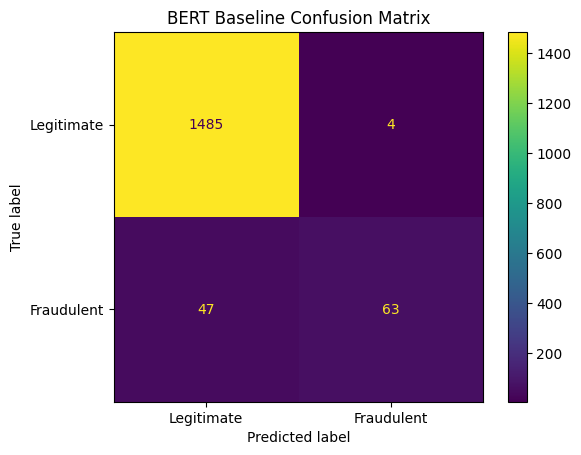

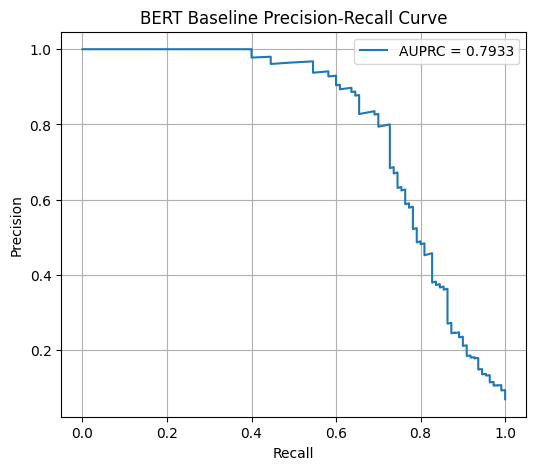

,model,threshold,loss,accuracy,precision,recall,f1,macro_f1,weighted_f1,auprc,average_precision
0,BERT Baseline Test,0.5,0.73173,0.968105,0.940299,0.572727,0.711864,0.847491,0.964458,0.79335,0.79384


In [40]:
# ============================================================
# 8. Train and evaluate baseline BERT before tuning
# ============================================================

baseline_params = {
    "learning_rate": BASELINE_LR,
    "batch_size": BASELINE_BATCH_SIZE,
    "epochs": BASELINE_EPOCHS,
    "weight_decay": BASELINE_WEIGHT_DECAY,
    "warmup_ratio": BASELINE_WARMUP_RATIO
}

bert_baseline_model, bert_baseline_val_metrics, bert_baseline_history = train_bert_run(
    train_dataset=bert_train_dataset,
    val_dataset=bert_val_dataset,
    params=baseline_params,
    class_weights=bert_class_weights,
    model_name="BERT Baseline",
    freeze_for_speed=False,
    save_path=None
)

display(bert_baseline_history)


# ============================================================
# 9. Baseline test evaluation
# ============================================================

bert_test_loader_baseline = make_loader(
    bert_test_dataset,
    BASELINE_BATCH_SIZE,
    shuffle=False
)

bert_baseline_test_metrics = evaluate_bert(
    bert_baseline_model,
    bert_test_loader_baseline,
    threshold=0.5,
    model_name="BERT Baseline Test",
    class_weights=bert_class_weights
)

plot_confusion(
    bert_baseline_test_metrics,
    "BERT Baseline Confusion Matrix"
)

plot_pr(
    bert_baseline_test_metrics,
    "BERT Baseline Precision-Recall Curve"
)

baseline_metrics_clean = remove_large_metric_arrays(
    bert_baseline_test_metrics
)

display(pd.DataFrame([baseline_metrics_clean]))

Random search tuning train size: 2610
Random search tuning validation size: 1598

BERT Random Search Trial 1/5
Params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 2, 'weight_decay': 0.01, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_7895/3097649529.py:112

Trainable parameters: 28,943,618 / 109,483,778 (26.4%)


/tmp/ipykernel_7895/3097649529.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...


BERT Random Search Trial 5 Val Epoch 2 Evaluation
loss              : 0.8702
accuracy          : 0.9337
precision         : 1.0000
recall            : 0.0275
f1                : 0.0536
macro_f1          : 0.5096
weighted_f1       : 0.9034
auprc             : 0.4624
average_precision : 0.4662

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.93      1.00      0.97      1489
  Fraudulent       1.00      0.03      0.05       109

    accuracy                           0.93      1598
   macro avg       0.97      0.51      0.51      1598
weighted avg       0.94      0.93      0.90      1598

BERT Random Search Trial 5 | Epoch 2/3 | Train Loss: 0.9243 | Val F1: 0.0536 | Val AUPRC: 0.4624


/tmp/ipykernel_7895/3097649529.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



BERT Random Search Trial 5 Val Epoch 3 Evaluation
loss              : 0.8057
accuracy          : 0.9393
precision         : 0.8333
recall            : 0.1376
f1                : 0.2362
macro_f1          : 0.6023
weighted_f1       : 0.9185
auprc             : 0.4905
average_precision : 0.4944

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      1.00      0.97      1489
  Fraudulent       0.83      0.14      0.24       109

    accuracy                           0.94      1598
   macro avg       0.89      0.57      0.60      1598
weighted avg       0.93      0.94      0.92      1598

BERT Random Search Trial 5 | Epoch 3/3 | Train Loss: 0.7440 | Val F1: 0.2362 | Val AUPRC: 0.4905
Trial 5 validation F1: 0.2362

BERT Random Search Complete
Best trial: 4
Best validation F1: 0.4344262295081967
Best params: {'learning_rate': 2e-05, 'batch_size': 16, 'epochs': 2, 'weight_decay': 0.0, 'warmup_ratio': 0.1}


,trial,state,learning_rate,batch_size,epochs,weight_decay,warmup_ratio,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_weighted_f1,val_auprc
3,4,COMPLETE,0.00002,16,2,0.00,0.1,0.482729,0.913642,0.392593,0.486239,0.434426,0.693839,0.917863,0.416724
1,2,COMPLETE,0.00001,8,2,0.00,0.1,0.796315,0.943680,0.827586,0.220183,0.347826,0.659198,0.928092,0.444881
2,3,COMPLETE,0.00001,8,2,0.00,0.0,0.834138,0.941176,0.800000,0.183486,0.298507,0.633904,0.923546,0.388542
0,1,COMPLETE,0.00003,8,2,0.01,0.0,0.831808,0.941176,1.000000,0.137615,0.241935,0.605668,0.919780,0.534584
4,5,COMPLETE,0.00001,8,3,0.00,0.1,0.805657,0.939299,0.833333,0.137615,0.236220,0.602307,0.918452,0.490460


Saved: bert_random_search_tuning_results.csv


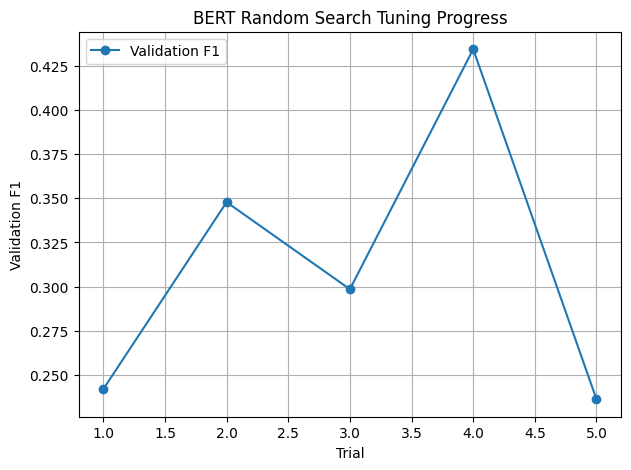

In [41]:
# ============================================================
# 10. Random search tuning on stratified subset
# ============================================================

bert_tune_train_dataset = get_stratified_subset(
    bert_train_dataset,
    y_train,
    fraction=TUNE_TRAIN_FRACTION,
    seed=42
)

bert_tune_val_dataset = get_stratified_subset(
    bert_val_dataset,
    y_val,
    fraction=TUNE_VAL_FRACTION,
    seed=42
)

print("Random search tuning train size:", len(bert_tune_train_dataset))
print("Random search tuning validation size:", len(bert_tune_val_dataset))


BERT_RANDOM_PARAM_SPACE = {
    "learning_rate": [1e-5, 2e-5, 3e-5],
    "batch_size": [8, 16],
    "epochs": [2, 3],
    "weight_decay": [0.0, 0.01],
    "warmup_ratio": [0.0, 0.1]
}


def sample_random_params(param_space):
    return {
        "learning_rate": random.choice(param_space["learning_rate"]),
        "batch_size": random.choice(param_space["batch_size"]),
        "epochs": random.choice(param_space["epochs"]),
        "weight_decay": random.choice(param_space["weight_decay"]),
        "warmup_ratio": random.choice(param_space["warmup_ratio"])
    }


def random_search_bert(
    n_trials,
    param_space,
    train_dataset,
    val_dataset,
    class_weights,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)

    tried_configs = set()
    results = []

    best_score = -1.0
    best_params = None
    best_trial_number = None

    for trial_idx in range(n_trials):
        params = sample_random_params(param_space)

        # Avoid duplicate parameter combinations when possible
        config_key = tuple(sorted(params.items()))
        retry_count = 0

        while config_key in tried_configs and retry_count < 20:
            params = sample_random_params(param_space)
            config_key = tuple(sorted(params.items()))
            retry_count += 1

        tried_configs.add(config_key)

        print("\n" + "=" * 72)
        print(f"BERT Random Search Trial {trial_idx + 1}/{n_trials}")
        print("=" * 72)
        print("Params:", params)

        model = None

        try:
            model, best_val_metrics, history = train_bert_run(
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                params=params,
                class_weights=class_weights,
                model_name=f"BERT Random Search Trial {trial_idx + 1}",
                freeze_for_speed=FREEZE_LOWER_LAYERS_DURING_TUNING,
                save_path=None
            )

            row = {
                "trial": trial_idx + 1,
                "state": "COMPLETE",
                "learning_rate": params["learning_rate"],
                "batch_size": params["batch_size"],
                "epochs": params["epochs"],
                "weight_decay": params["weight_decay"],
                "warmup_ratio": params["warmup_ratio"],
                "val_loss": best_val_metrics["loss"],
                "val_accuracy": best_val_metrics["accuracy"],
                "val_precision": best_val_metrics["precision"],
                "val_recall": best_val_metrics["recall"],
                "val_f1": best_val_metrics["f1"],
                "val_macro_f1": best_val_metrics["macro_f1"],
                "val_weighted_f1": best_val_metrics["weighted_f1"],
                "val_auprc": best_val_metrics["auprc"]
            }

            results.append(row)

            if best_val_metrics["f1"] > best_score:
                best_score = best_val_metrics["f1"]
                best_params = params.copy()
                best_trial_number = trial_idx + 1

            print(f"Trial {trial_idx + 1} validation F1: {best_val_metrics['f1']:.4f}")

        except RuntimeError as e:
            print(f"Trial {trial_idx + 1} failed with RuntimeError:")
            print(e)

            row = {
                "trial": trial_idx + 1,
                "state": "FAILED",
                "learning_rate": params["learning_rate"],
                "batch_size": params["batch_size"],
                "epochs": params["epochs"],
                "weight_decay": params["weight_decay"],
                "warmup_ratio": params["warmup_ratio"],
                "val_loss": None,
                "val_accuracy": None,
                "val_precision": None,
                "val_recall": None,
                "val_f1": None,
                "val_macro_f1": None,
                "val_weighted_f1": None,
                "val_auprc": None
            }

            results.append(row)

        finally:
            if model is not None:
                del model

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    results_df = pd.DataFrame(results)

    print("\n" + "=" * 72)
    print("BERT Random Search Complete")
    print("=" * 72)
    print("Best trial:", best_trial_number)
    print("Best validation F1:", best_score)
    print("Best params:", best_params)

    return best_params, best_score, best_trial_number, results_df


best_bert_params, best_bert_val_f1, best_bert_trial, bert_random_search_df = random_search_bert(
    n_trials=N_RANDOM_TRIALS,
    param_space=BERT_RANDOM_PARAM_SPACE,
    train_dataset=bert_tune_train_dataset,
    val_dataset=bert_tune_val_dataset,
    class_weights=bert_class_weights,
    seed=42
)

bert_random_search_df_sorted = bert_random_search_df.sort_values(
    "val_f1",
    ascending=False,
    na_position="last"
)

display(bert_random_search_df_sorted)

bert_random_search_df_sorted.to_csv(
    "bert_random_search_tuning_results.csv",
    index=False
)

print("Saved: bert_random_search_tuning_results.csv")


# Random search progress chart
completed_trials = bert_random_search_df[
    bert_random_search_df["state"] == "COMPLETE"
].sort_values("trial")

plt.figure(figsize=(7, 5))

plt.plot(
    completed_trials["trial"],
    completed_trials["val_f1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Trial")
plt.ylabel("Validation F1")
plt.title("BERT Random Search Tuning Progress")
plt.grid(True)
plt.legend()
plt.show()



Final tuned BERT params:
{'learning_rate': 2e-05, 'batch_size': 16, 'epochs': 3, 'weight_decay': 0.0, 'warmup_ratio': 0.1}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_7895/3097649529.py:112


BERT Random Search Tuned Full Train Val Epoch 1 Evaluation
loss              : 0.5641
accuracy          : 0.9574
precision         : 0.8596
recall            : 0.4495
f1                : 0.5904
macro_f1          : 0.7840
weighted_f1       : 0.9511
auprc             : 0.7281
average_precision : 0.7290

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.98      1489
  Fraudulent       0.86      0.45      0.59       109

    accuracy                           0.96      1598
   macro avg       0.91      0.72      0.78      1598
weighted avg       0.95      0.96      0.95      1598

BERT Random Search Tuned Full Train | Epoch 1/3 | Train Loss: 0.5885 | Val F1: 0.5904 | Val AUPRC: 0.7281


/tmp/ipykernel_7895/3097649529.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



BERT Random Search Tuned Full Train Val Epoch 2 Evaluation
loss              : 0.5481
accuracy          : 0.9700
precision         : 0.8861
recall            : 0.6422
f1                : 0.7447
macro_f1          : 0.8644
weighted_f1       : 0.9677
auprc             : 0.8292
average_precision : 0.8296

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.99      0.98      1489
  Fraudulent       0.89      0.64      0.74       109

    accuracy                           0.97      1598
   macro avg       0.93      0.82      0.86      1598
weighted avg       0.97      0.97      0.97      1598

BERT Random Search Tuned Full Train | Epoch 2/3 | Train Loss: 0.4105 | Val F1: 0.7447 | Val AUPRC: 0.8292


/tmp/ipykernel_7895/3097649529.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



BERT Random Search Tuned Full Train Val Epoch 3 Evaluation
loss              : 0.4872
accuracy          : 0.9768
precision         : 0.9091
recall            : 0.7339
f1                : 0.8122
macro_f1          : 0.8999
weighted_f1       : 0.9757
auprc             : 0.8529
average_precision : 0.8532

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      1489
  Fraudulent       0.91      0.73      0.81       109

    accuracy                           0.98      1598
   macro avg       0.94      0.86      0.90      1598
weighted avg       0.98      0.98      0.98      1598

BERT Random Search Tuned Full Train | Epoch 3/3 | Train Loss: 0.1773 | Val F1: 0.8122 | Val AUPRC: 0.8529


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_weighted_f1,val_auprc
0,1,0.588542,0.564148,0.957447,0.859649,0.449541,0.590361,0.783960,0.951147,0.728107
1,2,0.410512,0.548127,0.969962,0.886076,0.642202,0.744681,0.864362,0.967716,0.829217
2,3,0.177285,0.487194,0.976846,0.909091,0.733945,0.812183,0.899923,0.975693,0.852905


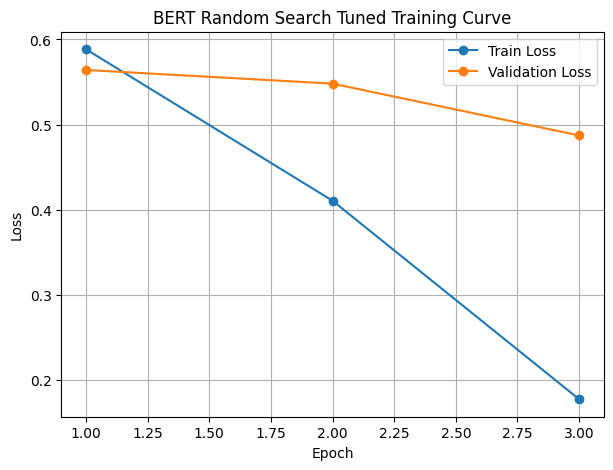


BERT Random Search Tuned Validation at 0.50 Threshold Evaluation
loss              : 0.4872
accuracy          : 0.9768
precision         : 0.9091
recall            : 0.7339
f1                : 0.8122
macro_f1          : 0.8999
weighted_f1       : 0.9757
auprc             : 0.8529
average_precision : 0.8532

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      1489
  Fraudulent       0.91      0.73      0.81       109

    accuracy                           0.98      1598
   macro avg       0.94      0.86      0.90      1598
weighted avg       0.98      0.98      0.98      1598

Best BERT validation threshold for F1: 0.0451
Best BERT validation F1 at threshold: 0.8246


In [42]:
# ============================================================
# 11. Final tuned BERT training on full training data
# ============================================================

final_bert_params = best_bert_params.copy()
final_bert_params["epochs"] = FINAL_EPOCHS

print("Final tuned BERT params:")
print(final_bert_params)

bert_tuned_model, bert_tuned_val_metrics_05, bert_tuned_history = train_bert_run(
    train_dataset=bert_train_dataset,
    val_dataset=bert_val_dataset,
    params=final_bert_params,
    class_weights=bert_class_weights,
    model_name="BERT Random Search Tuned Full Train",
    freeze_for_speed=False,
    save_path=None
)

display(bert_tuned_history)


# Tuned training curve
plt.figure(figsize=(7, 5))

plt.plot(
    bert_tuned_history["epoch"],
    bert_tuned_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    bert_tuned_history["epoch"],
    bert_tuned_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Random Search Tuned Training Curve")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 12. Threshold optimization on validation set
# ============================================================

bert_val_loader_tuned = make_loader(
    bert_val_dataset,
    final_bert_params["batch_size"],
    shuffle=False
)

bert_tuned_val_metrics_raw = evaluate_bert(
    bert_tuned_model,
    bert_val_loader_tuned,
    threshold=0.5,
    model_name="BERT Random Search Tuned Validation at 0.50 Threshold",
    class_weights=bert_class_weights
)

best_bert_threshold, best_bert_threshold_val_f1 = find_best_threshold_for_f1(
    bert_tuned_val_metrics_raw["labels"],
    bert_tuned_val_metrics_raw["probs"]
)

print(f"Best BERT validation threshold for F1: {best_bert_threshold:.4f}")
print(f"Best BERT validation F1 at threshold: {best_bert_threshold_val_f1:.4f}")


BERT Random Search Tuned Test Evaluation
loss              : 0.6890
accuracy          : 0.9700
precision         : 0.8039
recall            : 0.7455
f1                : 0.7736
macro_f1          : 0.8788
weighted_f1       : 0.9695
auprc             : 0.8352
average_precision : 0.8356

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      1489
  Fraudulent       0.80      0.75      0.77       110

    accuracy                           0.97      1599
   macro avg       0.89      0.87      0.88      1599
weighted avg       0.97      0.97      0.97      1599



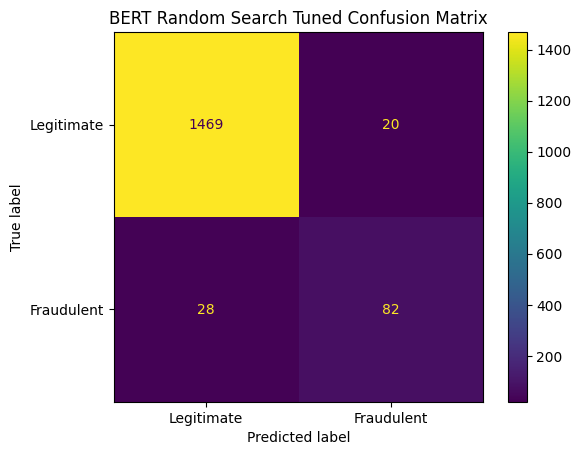

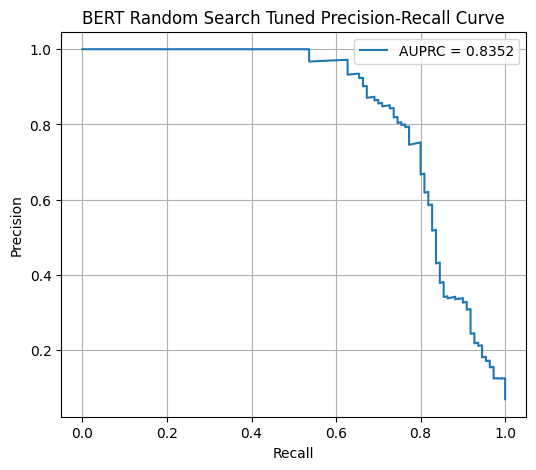

,model,threshold,loss,accuracy,precision,recall,f1,macro_f1,weighted_f1,auprc,average_precision
0,BERT Random Search Tuned Test,0.045105,0.688983,0.969981,0.803922,0.745455,0.773585,0.878755,0.969455,0.835222,0.835598


In [43]:
# ============================================================
# 13. Final tuned BERT test evaluation
# ============================================================

bert_test_loader_tuned = make_loader(
    bert_test_dataset,
    final_bert_params["batch_size"],
    shuffle=False
)

bert_tuned_test_metrics = evaluate_bert(
    bert_tuned_model,
    bert_test_loader_tuned,
    threshold=best_bert_threshold,
    model_name="BERT Random Search Tuned Test",
    class_weights=bert_class_weights
)

plot_confusion(
    bert_tuned_test_metrics,
    "BERT Random Search Tuned Confusion Matrix"
)

plot_pr(
    bert_tuned_test_metrics,
    "BERT Random Search Tuned Precision-Recall Curve"
)

tuned_metrics_clean = remove_large_metric_arrays(
    bert_tuned_test_metrics
)

display(pd.DataFrame([tuned_metrics_clean]))

,Model,Tuning,Threshold,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,AUPRC
0,BERT Baseline,None,0.500000,0.968105,0.940299,0.572727,0.711864,0.847491,0.964458,0.793350
1,BERT Tuned,Random Search,0.045105,0.969981,0.803922,0.745455,0.773585,0.878755,0.969455,0.835222


Saved: bert_baseline_vs_random_search_tuned_comparison.csv


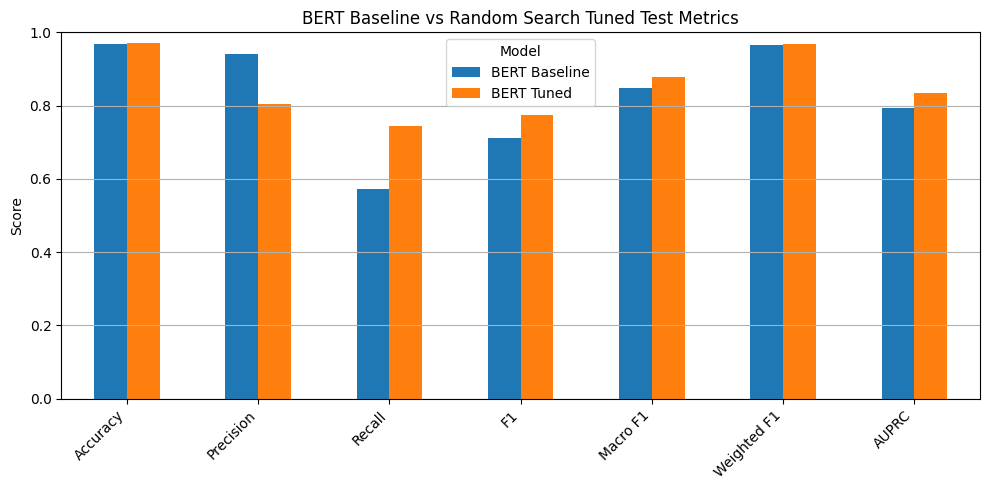

In [44]:
# ============================================================
# 14. Baseline vs random-search tuned BERT comparison
# ============================================================

bert_comparison = pd.DataFrame([
    {
        "Model": "BERT Baseline",
        "Tuning": "None",
        "Threshold": bert_baseline_test_metrics["threshold"],
        "Accuracy": bert_baseline_test_metrics["accuracy"],
        "Precision": bert_baseline_test_metrics["precision"],
        "Recall": bert_baseline_test_metrics["recall"],
        "F1": bert_baseline_test_metrics["f1"],
        "Macro F1": bert_baseline_test_metrics["macro_f1"],
        "Weighted F1": bert_baseline_test_metrics["weighted_f1"],
        "AUPRC": bert_baseline_test_metrics["auprc"]
    },
    {
        "Model": "BERT Tuned",
        "Tuning": "Random Search",
        "Threshold": bert_tuned_test_metrics["threshold"],
        "Accuracy": bert_tuned_test_metrics["accuracy"],
        "Precision": bert_tuned_test_metrics["precision"],
        "Recall": bert_tuned_test_metrics["recall"],
        "F1": bert_tuned_test_metrics["f1"],
        "Macro F1": bert_tuned_test_metrics["macro_f1"],
        "Weighted F1": bert_tuned_test_metrics["weighted_f1"],
        "AUPRC": bert_tuned_test_metrics["auprc"]
    }
])

display(bert_comparison)

bert_comparison.to_csv(
    "bert_baseline_vs_random_search_tuned_comparison.csv",
    index=False
)

print("Saved: bert_baseline_vs_random_search_tuned_comparison.csv")


metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Macro F1",
    "Weighted F1",
    "AUPRC"
]

comparison_plot = bert_comparison.set_index("Model")[metric_cols].T

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("BERT Baseline vs Random Search Tuned Test Metrics")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

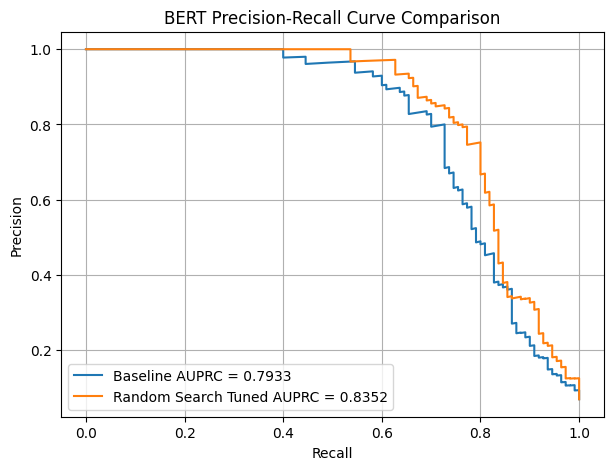

Saved: bert_random_search_summary.json


In [45]:
# ============================================================
# 15. Combined PR curve: baseline vs random-search tuned BERT
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    bert_baseline_test_metrics["recall_curve"],
    bert_baseline_test_metrics["precision_curve"],
    label=f"Baseline AUPRC = {bert_baseline_test_metrics['auprc']:.4f}"
)

plt.plot(
    bert_tuned_test_metrics["recall_curve"],
    bert_tuned_test_metrics["precision_curve"],
    label=f"Random Search Tuned AUPRC = {bert_tuned_test_metrics['auprc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("BERT Precision-Recall Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 16. Save final BERT summary
# ============================================================

bert_summary = {
    "runtime_config": {
        "max_length": MAX_LENGTH,
        "n_random_trials": N_RANDOM_TRIALS,
        "tune_train_fraction": TUNE_TRAIN_FRACTION,
        "tune_val_fraction": TUNE_VAL_FRACTION,
        "final_epochs": FINAL_EPOCHS,
        "freeze_lower_layers_during_tuning": FREEZE_LOWER_LAYERS_DURING_TUNING,
        "num_unfrozen_encoder_layers": NUM_UNFROZEN_ENCODER_LAYERS
    },
    "baseline_params": baseline_params,
    "random_search_param_space": BERT_RANDOM_PARAM_SPACE,
    "best_random_search_trial": int(best_bert_trial),
    "best_random_search_val_f1": float(best_bert_val_f1),
    "best_random_search_params": best_bert_params,
    "final_tuned_params": final_bert_params,
    "best_validation_threshold": float(best_bert_threshold),
    "best_validation_f1_at_threshold": float(best_bert_threshold_val_f1),
    "baseline_test_metrics": baseline_metrics_clean,
    "tuned_test_metrics": tuned_metrics_clean
}

with open("bert_random_search_summary.json", "w") as f:
    json.dump(bert_summary, f, indent=4)

print("Saved: bert_random_search_summary.json")


In [46]:
# ============================================================
# 17. Save BERT deployment bundle
# ============================================================

BERT_DEPLOYMENT_DIR = "bert_random_search_deployment_model"

if os.path.exists(BERT_DEPLOYMENT_DIR):
    shutil.rmtree(BERT_DEPLOYMENT_DIR)

os.makedirs(BERT_DEPLOYMENT_DIR, exist_ok=True)

bert_tuned_model.save_pretrained(BERT_DEPLOYMENT_DIR)
tokenizer_bert.save_pretrained(BERT_DEPLOYMENT_DIR)

bert_deployment_metadata = {
    "model_name": "BERT Random Search Tuned",
    "base_model": "bert-base-uncased",
    "task": "job_scam_binary_classification",
    "text_column": "full_text",
    "label_mapping": {
        "0": "Legitimate",
        "1": "Fraudulent"
    },
    "threshold": float(best_bert_threshold),
    "max_length": int(MAX_LENGTH),
    "best_random_search_params": best_bert_params,
    "final_tuned_params": final_bert_params,
    "test_metrics": tuned_metrics_clean
}

with open(os.path.join(BERT_DEPLOYMENT_DIR, "metadata.json"), "w") as f:
    json.dump(bert_deployment_metadata, f, indent=4)

# Optional metadata pkl.
# The actual transformer model should be loaded from the Hugging Face folder,
# not from a standalone pkl.
with open(os.path.join(BERT_DEPLOYMENT_DIR, "deployment_info.pkl"), "wb") as f:
    pickle.dump(bert_deployment_metadata, f)

print(f"Saved BERT deployment model to: {BERT_DEPLOYMENT_DIR}")


# ============================================================
# 18. Single job posting prediction function using tuned BERT
# ============================================================

def predict_job_scam_bert(
    text,
    model,
    tokenizer,
    device,
    threshold=None,
    max_length=MAX_LENGTH
):
    if threshold is None:
        threshold = best_bert_threshold

    model.eval()

    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        padding=True,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

        probs = torch.softmax(logits, dim=1)[0]

        fraud_probability = probs[1].item()
        legitimate_probability = probs[0].item()
        predicted_class = int(fraud_probability >= threshold)

    return {
        "predicted_class": predicted_class,
        "prediction_label": "Fraudulent" if predicted_class == 1 else "Legitimate",
        "legitimate_probability": legitimate_probability,
        "fraudulent_probability": fraud_probability,
        "threshold_used": threshold
    }


sample_job = """
TITLE: Data Entry Assistant
DESC: Work from home and earn high income weekly. No experience required.
Send your personal details and bank information for salary processing.
REQ: Basic computer skills.
COMPANY: missing
BENEFITS: Flexible working hours.
INDUSTRY: unknown
FUNCTION: unknown
"""

sample_prediction = predict_job_scam_bert(
    text=sample_job,
    model=bert_tuned_model,
    tokenizer=tokenizer_bert,
    device=device,
    threshold=best_bert_threshold,
    max_length=MAX_LENGTH
)

print(sample_prediction)


# ============================================================
# 19. How to load this BERT model later for deployment
# ============================================================

"""
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import json

DEPLOYMENT_DIR = "bert_random_search_deployment_model"

tokenizer = AutoTokenizer.from_pretrained(DEPLOYMENT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(DEPLOYMENT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

with open(f"{DEPLOYMENT_DIR}/metadata.json", "r") as f:
    metadata = json.load(f)

threshold = metadata["threshold"]
max_length = metadata["max_length"]
"""

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT deployment model to: bert_random_search_deployment_model
{'predicted_class': 1, 'prediction_label': 'Fraudulent', 'legitimate_probability': 0.0006009351345710456, 'fraudulent_probability': 0.9993990659713745, 'threshold_used': 0.045105110853910446}


'\nfrom transformers import AutoTokenizer, AutoModelForSequenceClassification\nimport torch\nimport json\n\nDEPLOYMENT_DIR = "bert_random_search_deployment_model"\n\ntokenizer = AutoTokenizer.from_pretrained(DEPLOYMENT_DIR)\nmodel = AutoModelForSequenceClassification.from_pretrained(DEPLOYMENT_DIR)\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nmodel = model.to(device)\n\nwith open(f"{DEPLOYMENT_DIR}/metadata.json", "r") as f:\n    metadata = json.load(f)\n\nthreshold = metadata["threshold"]\nmax_length = metadata["max_length"]\n'

## RoBERTa model

In [47]:
# Fix seed

import random
import numpy as np
import torch

def set_seed(seed=40):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(40)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [48]:
# Prepare dataset

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

train_dataset = TensorDataset(
    train_roberta["input_ids"],
    train_roberta["attention_mask"],
    y_train.long()
)

val_dataset = TensorDataset(
    val_roberta["input_ids"],
    val_roberta["attention_mask"],
    y_val.long()
)

test_dataset = TensorDataset(
    test_roberta["input_ids"],
    test_roberta["attention_mask"],
    y_test.long()
)

In [49]:
# Class weight

import numpy as np

def calculate_class_weights(y, device):
    labels = y.cpu().numpy()
    class_0 = np.sum(labels == 0)
    class_1 = np.sum(labels == 1)

    total = len(labels)
    weight_0 = total / (2 * class_0)
    weight_1 = total / (2 * class_1)

    weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)

    print("Class weights:", weights)
    return weights

class_weights = calculate_class_weights(y_train, device)

Class weights: tensor([0.5368, 7.2984], device='cuda:0')


In [50]:
# Load RoBERTa

from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

model.to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [51]:
# Training setup

from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import get_linear_schedule_with_warmup

batch_size = 16
epochs = 3
learning_rate = 2e-5
weight_decay = 0.01
warmup_ratio = 0.1

train_loader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

val_loader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

total_steps = len(train_loader) * epochs
warmup_steps = int(total_steps * warmup_ratio)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

loss_fn = CrossEntropyLoss(weight=class_weights)

In [52]:
# Evaluation function

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import f1_score

def evaluate(model, dataloader):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)
    auprc = auc(recall_curve, precision_curve)

    return {
      "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "auprc": auprc,
    "precision_curve": precision_curve,
    "recall_curve": recall_curve
    }

In [53]:
# Training loop - baseline

best_f1 = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()

    total_loss = 0

    for batch in train_loader:
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(train_loader)
    print("Train Loss:", avg_loss)

    val_metrics = evaluate(model, val_loader)
    print("Val F1:", val_metrics["f1"])

    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        best_model = model.state_dict()


Epoch 1/3
Train Loss: 0.6684062562412253
Val F1: 0.6024096385542169

Epoch 2/3
Train Loss: 0.5515693025523897
Val F1: 0.7473684210526316

Epoch 3/3
Train Loss: 0.37335297847076915
Val F1: 0.7980769230769231


These results suggest that the model is learning effectively across epochs, with training loss steadily decreasing and validation F1-score improving from 0.60 to 0.80, indicating better detection of fraudulent cases without clear signs of overfitting.

In [54]:
# Test evaluation

model.load_state_dict(best_model)

test_loader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=batch_size
)

test_metrics = evaluate(model, test_loader)

print("\n=== TEST RESULTS ===")
for k, v in test_metrics.items():
    if "curve" not in k:
        print(f"{k}: {v:.4f}")


=== TEST RESULTS ===
accuracy: 0.9694
precision: 0.8765
recall: 0.6455
f1: 0.7435
macro_f1: 0.8636
weighted_f1: 0.9672
auprc: 0.8172


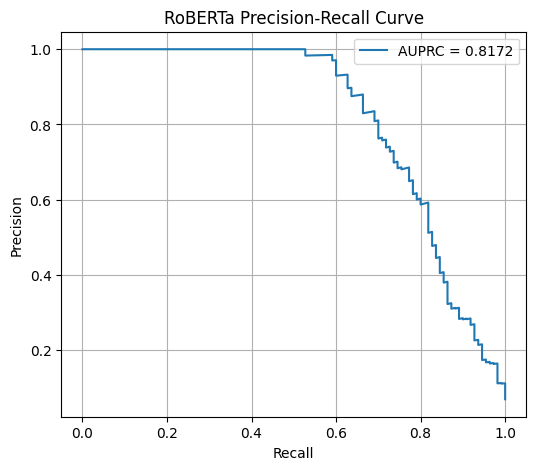

In [55]:
# PR Curve baseline model

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(
    test_metrics["recall_curve"],
    test_metrics["precision_curve"],
    label=f"AUPRC = {test_metrics['auprc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RoBERTa Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

The baseline model demonstrates strong overall performance, achieving high weighted F1-score (0.9672) and AUPRC (0.8172). However, the recall for fraudulent job postings is relatively lower (0.6455), indicating that a portion of fraudulent cases remains undetected. The difference between macro F1 (0.8636) and binary F1 (0.7435) further highlights the impact of class imbalance, motivating the need for hyperparameter tuning to improve minority class detection.

In [56]:
# Save baseline results

baseline_metrics = test_metrics

In [57]:
# Define Training Function (for tuning)

def train_one_run(params, train_dataset, val_dataset, class_weights):

    from transformers import RobertaForSequenceClassification
    from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
    from torch.optim import AdamW
    from torch.nn import CrossEntropyLoss
    from transformers import get_linear_schedule_with_warmup

    model = RobertaForSequenceClassification.from_pretrained(
        "roberta-base",
        num_labels=2
    ).to(device)

    train_loader = DataLoader(
        train_dataset,
        sampler=RandomSampler(train_dataset),
        batch_size=params["batch_size"]
    )

    val_loader = DataLoader(
        val_dataset,
        sampler=SequentialSampler(val_dataset),
        batch_size=params["batch_size"]
    )

    optimizer = AdamW(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    total_steps = len(train_loader) * params["epochs"]
    warmup_steps = int(total_steps * params["warmup_ratio"])

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    loss_fn = CrossEntropyLoss(weight=class_weights)

    best_f1 = 0
    best_state = None

    for epoch in range(params["epochs"]):
        model.train()

        for batch in train_loader:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            model.zero_grad()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            loss = loss_fn(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

        val_metrics = evaluate(model, val_loader)

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = model.state_dict()

    return best_f1, best_state

In [58]:
# Define tuning criteria
import random

search_space = {
    "learning_rate": [1e-5, 2e-5, 3e-5],
    "batch_size": [8, 16],
    "epochs": [2, 3],
    "weight_decay": [0.0, 0.01],
    "warmup_ratio": [0.0, 0.1]
}

def sample_params():
    return {k: random.choice(v) for k, v in search_space.items()}

In [59]:
# Run tuning

num_trials = 5
results = []

for i in range(num_trials):
    params = sample_params()
    print(f"\n=== Trial {i+1} ===")
    print(params)

    f1, state = train_one_run(
        params,
        train_dataset,
        val_dataset,
        class_weights
    )

    print(f"Validation F1: {f1:.4f}")

    results.append({
        "params": params,
        "f1": f1,
        "state": state
    })


=== Trial 1 ===
{'learning_rate': 2e-05, 'batch_size': 8, 'epochs': 2, 'weight_decay': 0.01, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Validation F1: 0.7380

=== Trial 2 ===
{'learning_rate': 1e-05, 'batch_size': 16, 'epochs': 3, 'weight_decay': 0.01, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Validation F1: 0.7879

=== Trial 5 ===
{'learning_rate': 2e-05, 'batch_size': 8, 'epochs': 2, 'weight_decay': 0.01, 'warmup_ratio': 0.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Validation F1: 0.5517


In [60]:
# Select best model

best_trial = max(results, key=lambda x: x["f1"])

best_params = best_trial["params"]
best_state = best_trial["state"]

print("\nBest Params:", best_params)
print("Best Val F1:", best_trial["f1"])


Best Params: {'learning_rate': 1e-05, 'batch_size': 8, 'epochs': 3, 'weight_decay': 0.0, 'warmup_ratio': 0.1}
Best Val F1: 0.7878787878787878


In [61]:
# Load best model

from transformers import RobertaForSequenceClassification

best_model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

best_model.load_state_dict(best_state)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<All keys matched successfully>

In [63]:
# Save to PKL file

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

best_model.save_pretrained("./tuned_roberta_model")
tokenizer.save_pretrained("./tuned_roberta_model")

print("Tuned model saved as tuned_roberta_model.pkl")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Tuned model saved as tuned_roberta_model.pkl


#### **How to load saved model for deployment?**

from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch

MODEL_DIR = "./tuned_roberta_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

model.eval()


In [64]:
# Final test evaluation

from torch.utils.data import DataLoader, SequentialSampler

test_loader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=best_params["batch_size"]
)

test_metrics = evaluate(best_model, test_loader)

print("\n=== TUNED TEST RESULTS ===")
for k, v in test_metrics.items():
    if "curve" not in k:
        print(f"{k}: {v:.4f}")


=== TUNED TEST RESULTS ===
accuracy: 0.9744
precision: 0.9259
recall: 0.6818
f1: 0.7853
macro_f1: 0.8859
weighted_f1: 0.9725
auprc: 0.8407


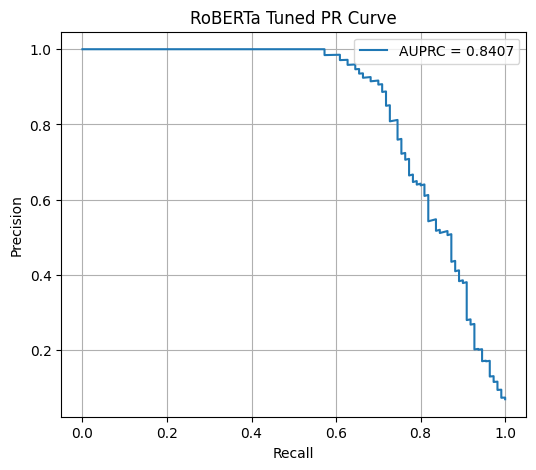

In [65]:
# PR curve tuned model

plt.figure(figsize=(6,5))
plt.plot(
    test_metrics["recall_curve"],
    test_metrics["precision_curve"],
    label=f"AUPRC = {test_metrics['auprc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RoBERTa Tuned PR Curve")
plt.legend()
plt.grid(True)
plt.show()

In [66]:
# Compare baseline vs tuned RoBERTa

import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "Baseline",
        "Accuracy": baseline_metrics["accuracy"],
        "Precision": baseline_metrics["precision"],
        "Recall": baseline_metrics["recall"],
        "F1": baseline_metrics["f1"],
        "Macro F1": baseline_metrics["macro_f1"],
        "Weighted F1": baseline_metrics["weighted_f1"],
        "AUPRC": baseline_metrics["auprc"]
    },
    {
        "Model": "Tuned",
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "Macro F1": test_metrics["macro_f1"],
        "Weighted F1": test_metrics["weighted_f1"],
        "AUPRC": test_metrics["auprc"]
    }
])

print(comparison)

      Model  Accuracy  Precision    Recall        F1  Macro F1  Weighted F1  \
0  Baseline  0.969356   0.876543  0.645455  0.743455  0.863580     0.967177   
1     Tuned  0.974359   0.925926  0.681818  0.785340  0.885853     0.972536   

      AUPRC  
0  0.817155  
1  0.840704  


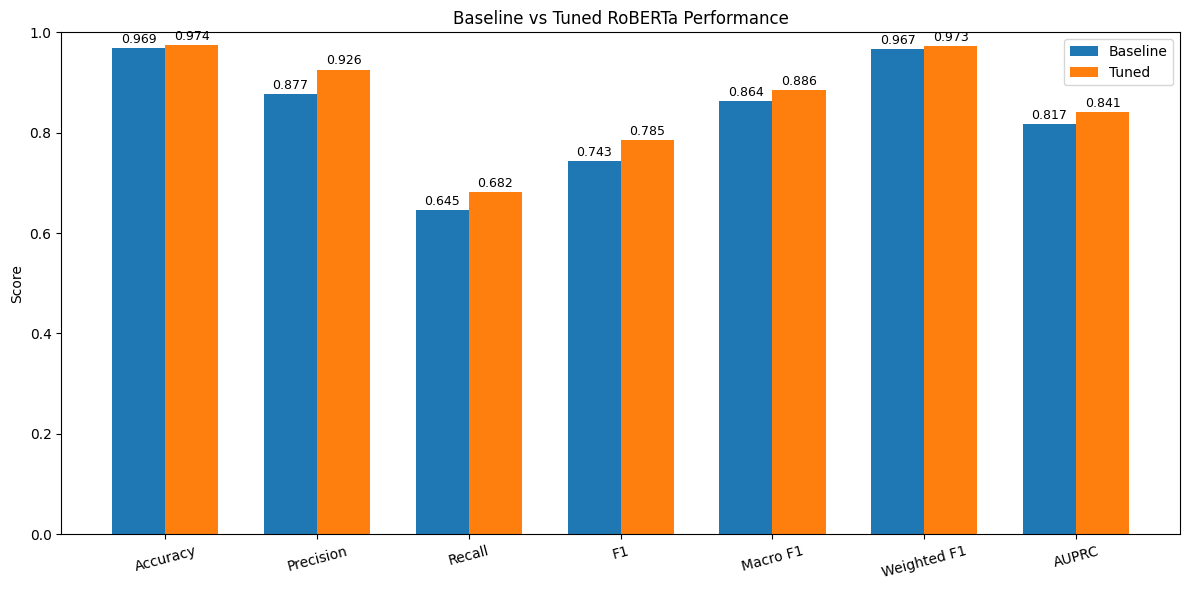

In [67]:
# Plot comparison graph

# Metrics to plot
metrics = ["Accuracy", "Precision", "Recall", "F1", "Macro F1", "Weighted F1", "AUPRC"]

# Values
baseline_values = comparison.loc[comparison["Model"] == "Baseline", metrics].values[0]
tuned_values = comparison.loc[comparison["Model"] == "Tuned", metrics].values[0]

# Bar positions
x = np.arange(len(metrics))
width = 0.35

# Create figure
plt.figure(figsize=(12, 6))

# Plot bars
plt.bar(x - width/2, baseline_values, width, label="Baseline")
plt.bar(x + width/2, tuned_values, width, label="Tuned")

# Labels and formatting
plt.xticks(x, metrics, rotation=15)
plt.ylabel("Score")
plt.title("Baseline vs Tuned RoBERTa Performance")
plt.ylim(0, 1)
plt.legend()

# Show values on top of bars
for i, v in enumerate(baseline_values):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

for i, v in enumerate(tuned_values):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

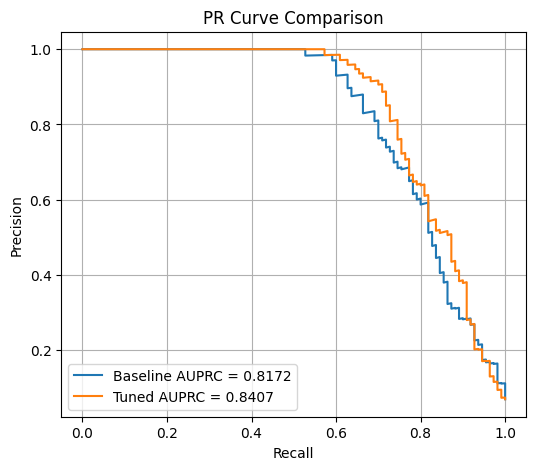

In [68]:
# Combine PR curve

plt.figure(figsize=(6,5))

plt.plot(
    baseline_metrics["recall_curve"],
    baseline_metrics["precision_curve"],
    label=f"Baseline AUPRC = {baseline_metrics['auprc']:.4f}"
)

plt.plot(
    test_metrics["recall_curve"],
    test_metrics["precision_curve"],
    label=f"Tuned AUPRC = {test_metrics['auprc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

- The **tuned model outperforms the baseline** across all evaluation metrics, indicating that the hyperparameter adjustments led to a more effective model overall.

- The **increase in F1 score** from 0.7435 to 0.7853 shows a **better balance between precision and recall**, meaning the model is making more reliable predictions.

- The substantial **improvement in precision** demonstrates that the **tuned model produces fewer false positives**, making its positive predictions more trustworthy.

- The **improvement in recall indicates that the model is also identifying more true positive cases**, although this remains the main area for further enhancement.

- The **higher macro F1 score suggests improved performance across classe**, reflecting better handling of class imbalance.

- The **increase in weighted F1 and accuracy confirms that overall prediction performance has improved**, particularly on the majority class.

- Finally, **the higher AUPRC indicates that the tuned model has better ranking capability**, meaning it distinguishes more effectively between positive and negative samples across different thresholds.

## Comparison & Evaluation of BERT & RoBERTa

,Model,Tuning Method,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1,AUPRC
0,BERT,Random Search,0.969981,0.803922,0.745455,0.773585,0.878755,0.969455,0.835222
1,RoBERTa,Random Search,0.974359,0.925926,0.681818,0.785340,0.885853,0.972536,0.840704


Saved: bert_vs_roberta_final_comparison.csv


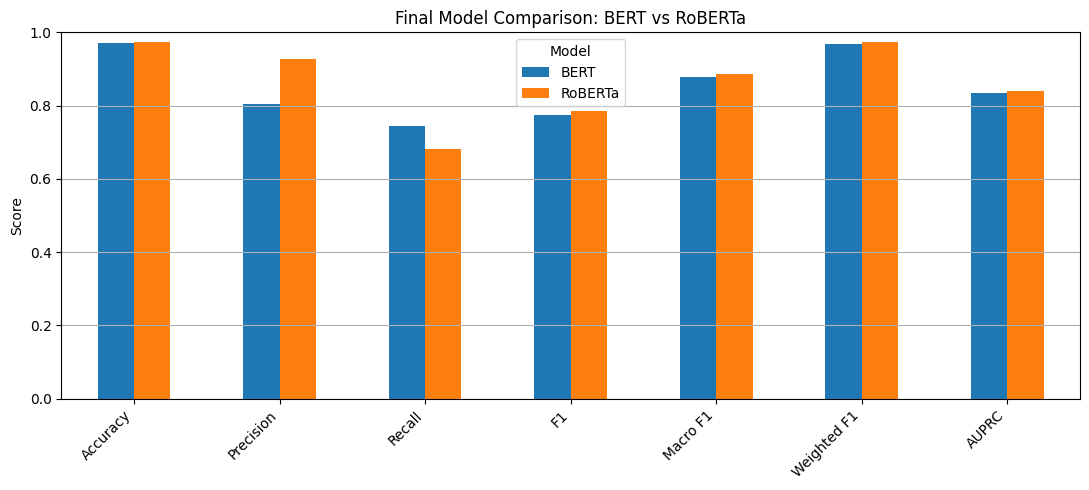

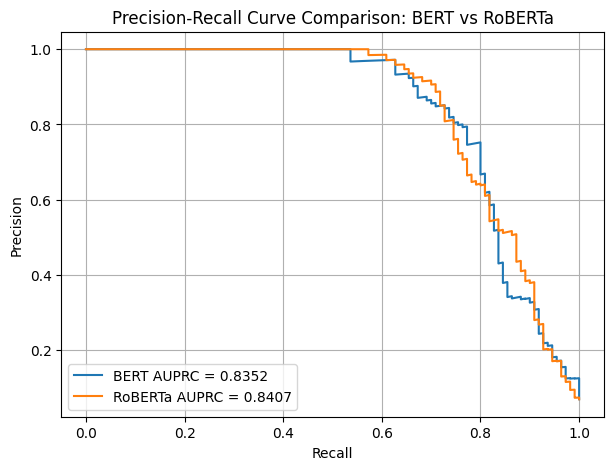


Best model based on F1-score:
Model                  RoBERTa
Tuning Method    Random Search
Accuracy              0.974359
Precision             0.925926
Recall                0.681818
F1                     0.78534
Macro F1              0.885853
Weighted F1           0.972536
AUPRC                 0.840704
Name: 1, dtype: object


In [69]:
bert_final_metrics = bert_tuned_test_metrics
roberta_final_metrics = test_metrics

final_model_comparison = pd.DataFrame([
    {
        "Model": "BERT",
        "Tuning Method": "Random Search",
        "Accuracy": bert_final_metrics["accuracy"],
        "Precision": bert_final_metrics["precision"],
        "Recall": bert_final_metrics["recall"],
        "F1": bert_final_metrics["f1"],
        "Macro F1": bert_final_metrics["macro_f1"],
        "Weighted F1": bert_final_metrics["weighted_f1"],
        "AUPRC": bert_final_metrics["auprc"]
    },
    {
        "Model": "RoBERTa",
        "Tuning Method": "Random Search",
        "Accuracy": roberta_final_metrics["accuracy"],
        "Precision": roberta_final_metrics["precision"],
        "Recall": roberta_final_metrics["recall"],
        "F1": roberta_final_metrics["f1"],
        "Macro F1": roberta_final_metrics["macro_f1"],
        "Weighted F1": roberta_final_metrics["weighted_f1"],
        "AUPRC": roberta_final_metrics["auprc"]
    }
])

display(final_model_comparison)

# Optional: save comparison table
final_model_comparison.to_csv(
    "bert_vs_roberta_final_comparison.csv",
    index=False
)

print("Saved: bert_vs_roberta_final_comparison.csv")


# ------------------------------------------------------------
# 2. Metric comparison bar chart
# ------------------------------------------------------------

metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Macro F1",
    "Weighted F1",
    "AUPRC"
]

comparison_plot = final_model_comparison.set_index("Model")[metric_cols].T

comparison_plot.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Model Comparison: BERT vs RoBERTa")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Precision-Recall curve comparison
# ------------------------------------------------------------
# BERT PR curve is reconstructed from bert_test_labels and bert_test_probs.
# RoBERTa PR curve is already stored in test_metrics.

from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(7, 5))

plt.plot(
    bert_final_metrics["recall_curve"],
    bert_final_metrics["precision_curve"],
    label=f"BERT AUPRC = {bert_final_metrics['auprc']:.4f}"
)

plt.plot(
    roberta_final_metrics["recall_curve"],
    roberta_final_metrics["precision_curve"],
    label=f"RoBERTa AUPRC = {roberta_final_metrics['auprc']:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison: BERT vs RoBERTa")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 4. Automatically identify the best model
# ------------------------------------------------------------

selection_metric = "F1"

best_model_row = final_model_comparison.sort_values(
    selection_metric,
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]
best_model_f1 = best_model_row["F1"]
best_model_precision = best_model_row["Precision"]
best_model_recall = best_model_row["Recall"]
best_model_auprc = best_model_row["AUPRC"]

print("\nBest model based on F1-score:")
print(best_model_row)


## Final Model Evaluation: BERT vs RoBERTa

- Both **BERT** and **RoBERTa** were fine-tuned using **Random Search**, so the comparison is fair and consistent.

- Based on the final test results, **RoBERTa is selected as the best overall model**.

- **Why RoBERTa performs better overall:**
  - RoBERTa achieved the highest **F1-score**:  
    **RoBERTa = 0.7853**, BERT = 0.7736
  - RoBERTa achieved the highest **Accuracy**:  
    **RoBERTa = 0.9744**, BERT = 0.9700
  - RoBERTa achieved much higher **Precision**:  
    **RoBERTa = 0.9259**, BERT = 0.8039
  - RoBERTa also achieved the highest **Macro F1**, **Weighted F1**, and **AUPRC**.

- **BERT still has one important advantage:**
  - BERT achieved higher **Recall**:  
    **BERT = 0.7455**, RoBERTa = 0.6818
  - This means BERT detected more fraudulent job postings, but it also produced more false positives.

- **RoBERTa is more reliable for deployment because:**
  - It gives a better balance between precision and recall.
  - It reduces false scam predictions.
  - It has stronger overall performance across most evaluation metrics.
  - Its Precision-Recall curve also shows a slightly higher AUPRC score.

- **Final conclusion:**
  - Best overall model: **RoBERTa**
  - Best F1-score: **RoBERTa**
  - Best precision: **RoBERTa**
  - Best recall: **BERT**
  - Best deployment candidate: **RoBERTa**

- Therefore, **RoBERTa is selected as the final model for the job scam detection system**, as it provides the strongest overall balance between detecting fraudulent jobs and avoiding incorrect scam classifications.